In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzAx'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 12

# On fixe la graine pour que les exemples soient reproductibles
np.random.seed(42)

print("✅ Tout est prêt")

✅ Tout est prêt


In [3]:
# Tailles de 10 personnes (en cm)
tailles = np.array([165, 172, 180, 158, 175, 168, 183, 170, 162, 177])

moyenne = np.mean(tailles)
print(f"Tailles : {tailles}")
print(f"Moyenne : {moyenne:.1f} cm")

Tailles : [165 172 180 158 175 168 183 170 162 177]
Moyenne : 171.0 cm


In [4]:
# Avec 9 personnes normales et un géant de 250 cm
tailles_avec_geant = np.array([165, 172, 180, 158, 175, 168, 183, 170, 162, 250])
print(f"Sans le géant : moyenne = {np.mean(tailles[:9]):.1f} cm")
print(f"Avec le géant : moyenne = {np.mean(tailles_avec_geant):.1f} cm")
print("→ Un seul outlier a fait grimper la moyenne de 4 cm !")

Sans le géant : moyenne = 170.3 cm
Avec le géant : moyenne = 178.3 cm
→ Un seul outlier a fait grimper la moyenne de 4 cm !


In [5]:
mediane = np.median(tailles)
print(f"Tailles triées : {sorted(tailles)}")
print(f"Médiane : {mediane:.1f} cm")

Tailles triées : [np.int64(158), np.int64(162), np.int64(165), np.int64(168), np.int64(170), np.int64(172), np.int64(175), np.int64(177), np.int64(180), np.int64(183)]
Médiane : 171.0 cm


In [6]:
print(f"Médiane sans géant : {np.median(tailles[:9]):.1f}")
print(f"Médiane avec géant : {np.median(tailles_avec_geant):.1f}")
print("→ La médiane n'a presque pas bougé !")

Médiane sans géant : 170.0
Médiane avec géant : 171.0
→ La médiane n'a presque pas bougé !


In [7]:
from collections import Counter

couleurs_voitures = ["rouge", "bleu", "rouge", "vert", "bleu", "rouge", "noir"]
compteur = Counter(couleurs_voitures)
mode, occurrences = compteur.most_common(1)[0]
print(f"Mode : '{mode}' (apparaît {occurrences} fois)")
print(f"Tous les comptes : {dict(compteur)}")

Mode : 'rouge' (apparaît 3 fois)
Tous les comptes : {'rouge': 3, 'bleu': 2, 'vert': 1, 'noir': 1}


In [8]:
notes_A = np.array([10, 10, 10, 10, 10])
notes_B = np.array([5, 15, 2, 18, 10])

print(f"Groupe A : étendue = {notes_A.max() - notes_A.min()}")
print(f"Groupe B : étendue = {notes_B.max() - notes_B.min()}")

Groupe A : étendue = 0
Groupe B : étendue = 16


In [9]:
print(f"Groupe A : écart-type = {np.std(notes_A):.2f}")
print(f"Groupe B : écart-type = {np.std(notes_B):.2f}")

Groupe A : écart-type = 0.00
Groupe B : écart-type = 5.97


In [10]:
print(f"Variance groupe B : {np.var(notes_B):.2f}")
print(f"Écart-type²       : {np.std(notes_B)**2:.2f}")
print("→ Les deux sont identiques (variance = écart-type²)")

Variance groupe B : 35.60
Écart-type²       : 35.60
→ Les deux sont identiques (variance = écart-type²)


In [11]:
# Exemple : salaires (en k€/an)
salaires = np.array([22, 25, 28, 30, 32, 35, 38, 40, 45, 48, 55, 62, 80, 150])

q1 = np.percentile(salaires, 25)
q2 = np.percentile(salaires, 50)
q3 = np.percentile(salaires, 75)
iqr = q3 - q1

print(f"Salaires (triés) : {salaires}")
print(f"Q1 (25%)  : {q1:.1f} k€")
print(f"Q2 (50%)  : {q2:.1f} k€  ← médiane")
print(f"Q3 (75%)  : {q3:.1f} k€")
print(f"IQR       : {iqr:.1f} k€")
print(f"Moyenne   : {np.mean(salaires):.1f} k€  (tirée vers le haut par le 150)")

Salaires (triés) : [ 22  25  28  30  32  35  38  40  45  48  55  62  80 150]
Q1 (25%)  : 30.5 k€
Q2 (50%)  : 39.0 k€  ← médiane
Q3 (75%)  : 53.2 k€
IQR       : 22.8 k€
Moyenne   : 49.3 k€  (tirée vers le haut par le 150)


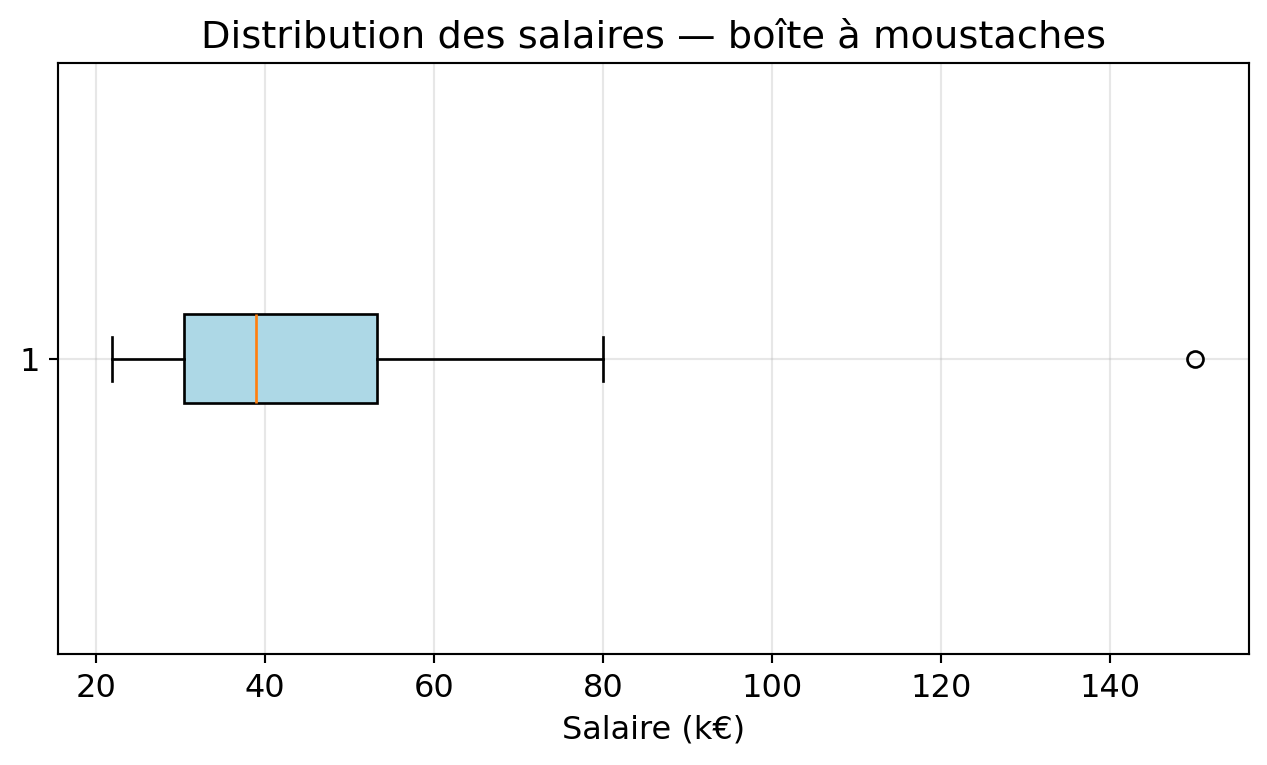

In [12]:
#| label: fig-boxplot-salaires
#| fig-cap: 'La boxplot : la synthèse visuelle parfaite'
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(salaires, vert=False, patch_artist=True, 
           boxprops=dict(facecolor='lightblue'))
ax.set_xlabel('Salaire (k€)')
ax.set_title("Distribution des salaires — boîte à moustaches")
ax.grid(True, alpha=0.3)
plt.show()

In [13]:
#| eval: false
# TODO: Exercice 1

notes = np.array([12, 14, 8, 15, 10, 11, 13, 16, 9, 14, 
                  11, 12, 15, 10, 13, 14, 12, 18, 9, 11, 
                  13, 15, 10, 12, 14, 11, 13, 20, 8, 12])

# 1. Statistiques


# 2. Histogramme et boxplot côte à côte


# 3-4. Interprétation dans une cellule markdown ci-dessous

Moyenne     : 12.50
Médiane     : 12.00
Écart-type  : 2.72
Q1          : 11.00
Q3          : 14.00
IQR         : 3.00


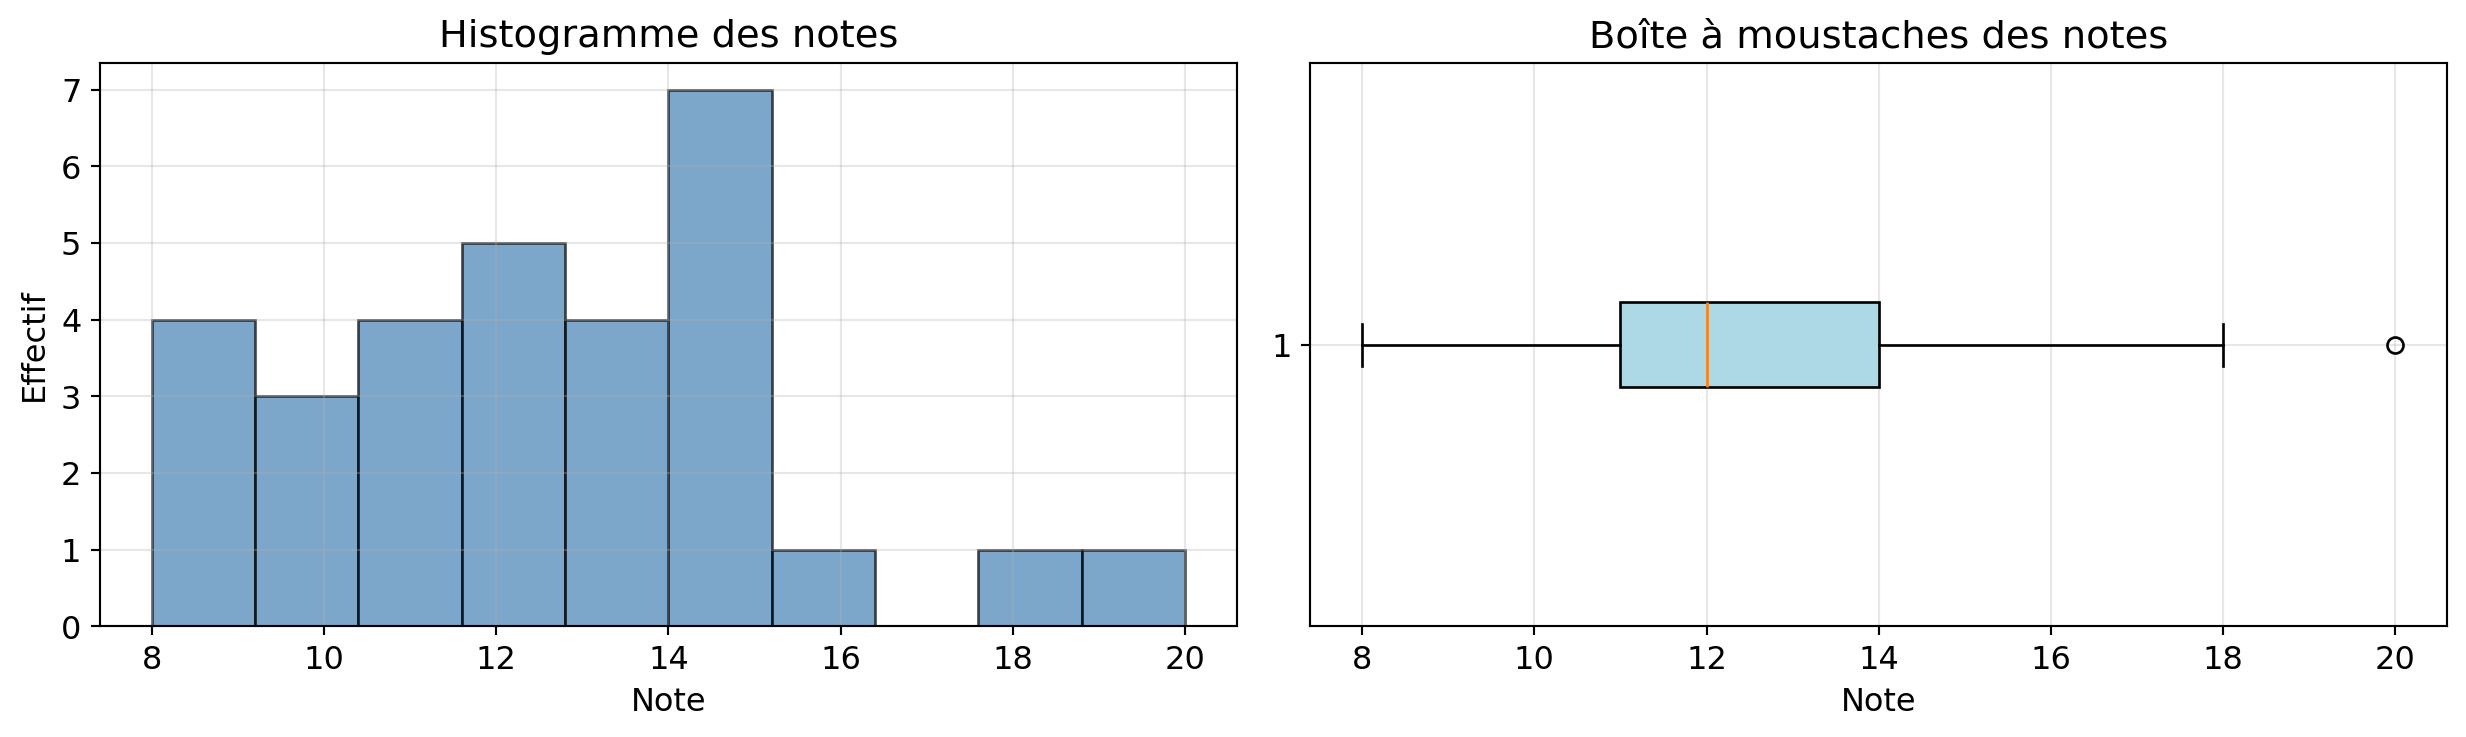

In [14]:
notes = np.array([12, 14, 8, 15, 10, 11, 13, 16, 9, 14, 
                  11, 12, 15, 10, 13, 14, 12, 18, 9, 11, 
                  13, 15, 10, 12, 14, 11, 13, 20, 8, 12])

# 1. Statistiques
print(f"Moyenne     : {np.mean(notes):.2f}")
print(f"Médiane     : {np.median(notes):.2f}")
print(f"Écart-type  : {np.std(notes):.2f}")
print(f"Q1          : {np.percentile(notes, 25):.2f}")
print(f"Q3          : {np.percentile(notes, 75):.2f}")
print(f"IQR         : {np.percentile(notes, 75) - np.percentile(notes, 25):.2f}")

# 2. Visualisations
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(notes, bins=10, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title("Histogramme des notes")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Effectif")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(notes, vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title("Boîte à moustaches des notes")
axes[1].set_xlabel("Note")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

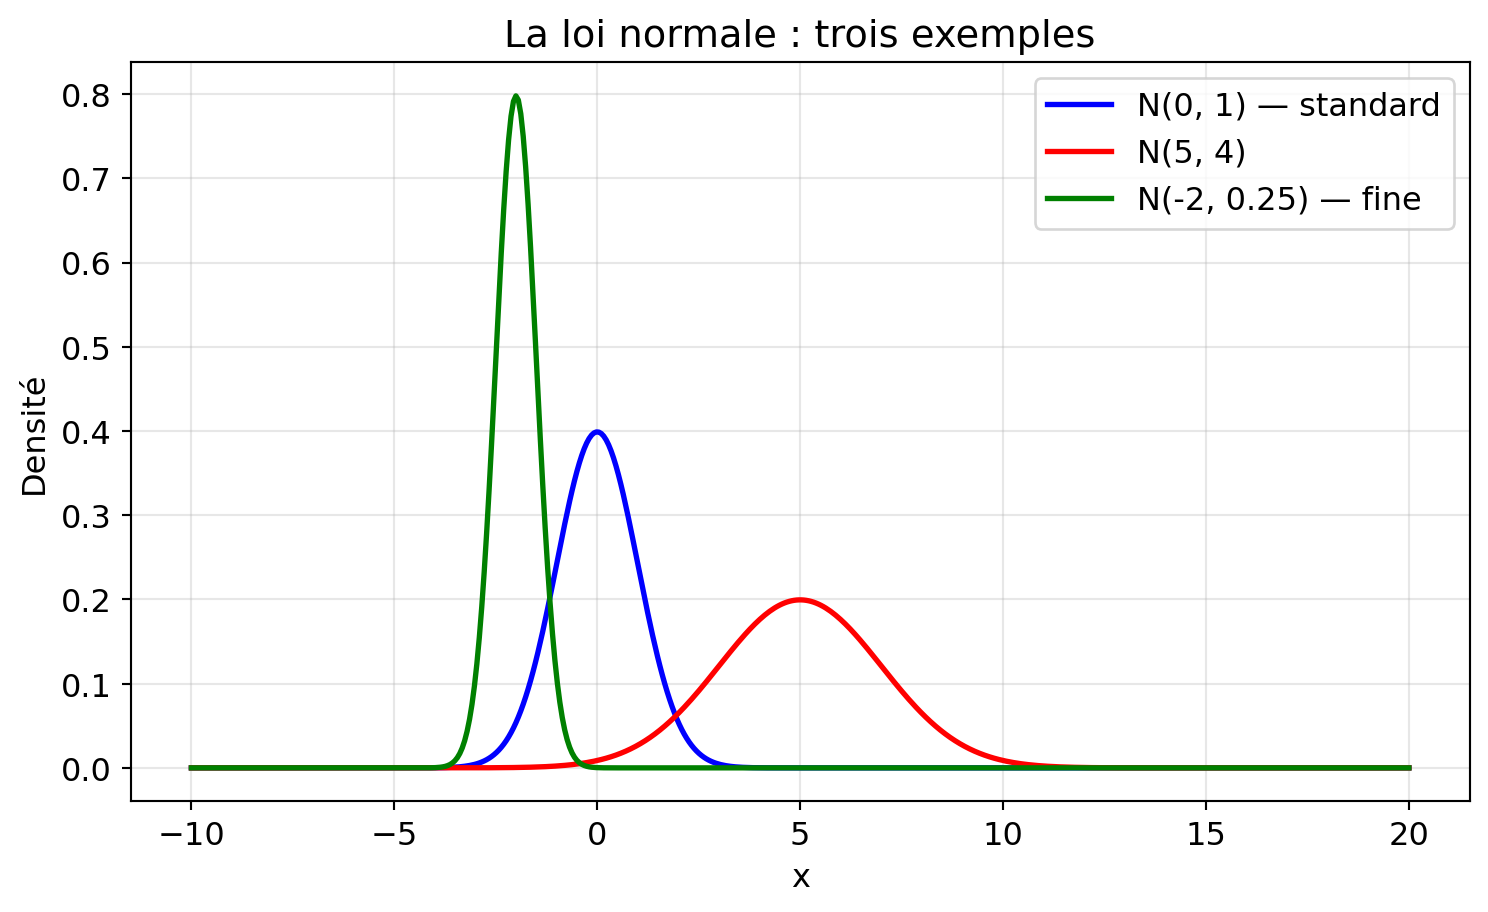

In [15]:
#| label: fig-loi-normale
#| fig-cap: La loi normale pour différents paramètres
x = np.linspace(-10, 20, 500)

fig, ax = plt.subplots()
# Formule de la densité de probabilité
def densite_normale(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

ax.plot(x, densite_normale(x, 0, 1), 'b-', linewidth=2, label='N(0, 1) — standard')
ax.plot(x, densite_normale(x, 5, 2), 'r-', linewidth=2, label='N(5, 4)')
ax.plot(x, densite_normale(x, -2, 0.5), 'g-', linewidth=2, label='N(-2, 0.25) — fine')

ax.set_xlabel('x')
ax.set_ylabel('Densité')
ax.set_title("La loi normale : trois exemples")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

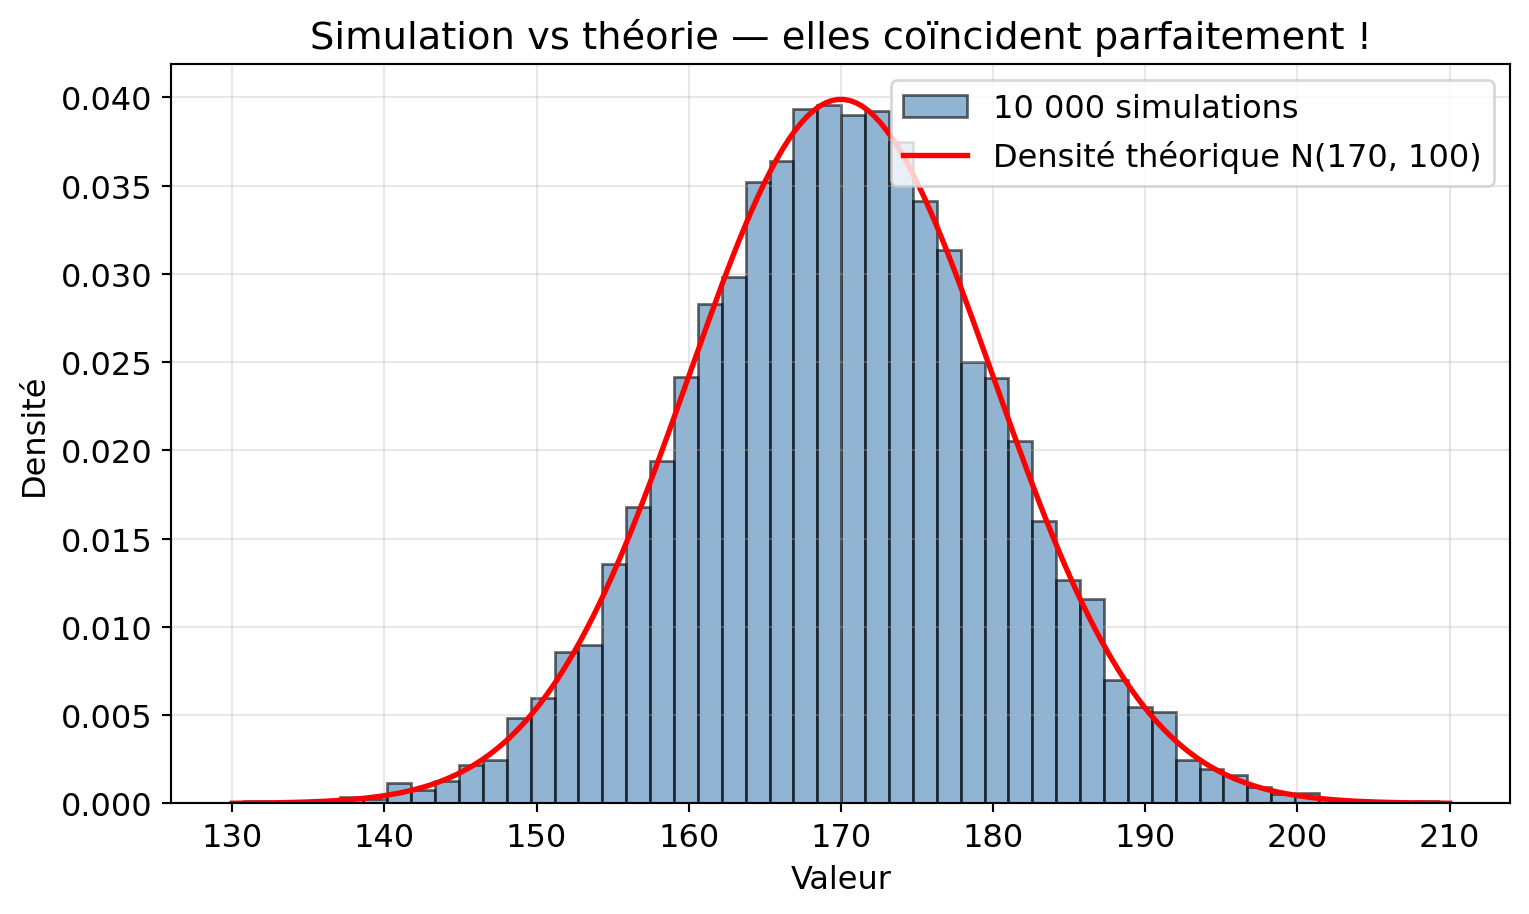

Moyenne simulée    : 169.98  (attendu : 170)
Écart-type simulé  : 10.03   (attendu : 10)


In [16]:
#| label: fig-normale-simule
#| fig-cap: Simulation vs formule théorique
# Simuler 10 000 tirages d'une loi normale N(170, 10)
tirages = np.random.normal(loc=170, scale=10, size=10000)

fig, ax = plt.subplots()
ax.hist(tirages, bins=50, density=True, alpha=0.6, color='steelblue', 
        edgecolor='black', label='10 000 simulations')

# Superposer la densité théorique
x_theo = np.linspace(130, 210, 200)
ax.plot(x_theo, densite_normale(x_theo, 170, 10), 'r-', linewidth=2, 
        label='Densité théorique N(170, 100)')

ax.set_xlabel('Valeur')
ax.set_ylabel('Densité')
ax.set_title("Simulation vs théorie — elles coïncident parfaitement !")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Moyenne simulée    : {tirages.mean():.2f}  (attendu : 170)")
print(f"Écart-type simulé  : {tirages.std():.2f}   (attendu : 10)")

In [17]:
# Vérifions sur nos 10 000 tirages
mu = tirages.mean()
sigma = tirages.std()

proportion_1sigma = np.mean((tirages > mu - sigma) & (tirages < mu + sigma))
proportion_2sigma = np.mean((tirages > mu - 2*sigma) & (tirages < mu + 2*sigma))
proportion_3sigma = np.mean((tirages > mu - 3*sigma) & (tirages < mu + 3*sigma))

print(f"Dans [μ - σ, μ + σ]    : {proportion_1sigma:.1%}  (attendu : 68%)")
print(f"Dans [μ - 2σ, μ + 2σ]  : {proportion_2sigma:.1%}  (attendu : 95%)")
print(f"Dans [μ - 3σ, μ + 3σ]  : {proportion_3sigma:.1%}  (attendu : 99.7%)")

Dans [μ - σ, μ + σ]    : 68.4%  (attendu : 68%)
Dans [μ - 2σ, μ + 2σ]  : 95.4%  (attendu : 95%)
Dans [μ - 3σ, μ + 3σ]  : 99.7%  (attendu : 99.7%)


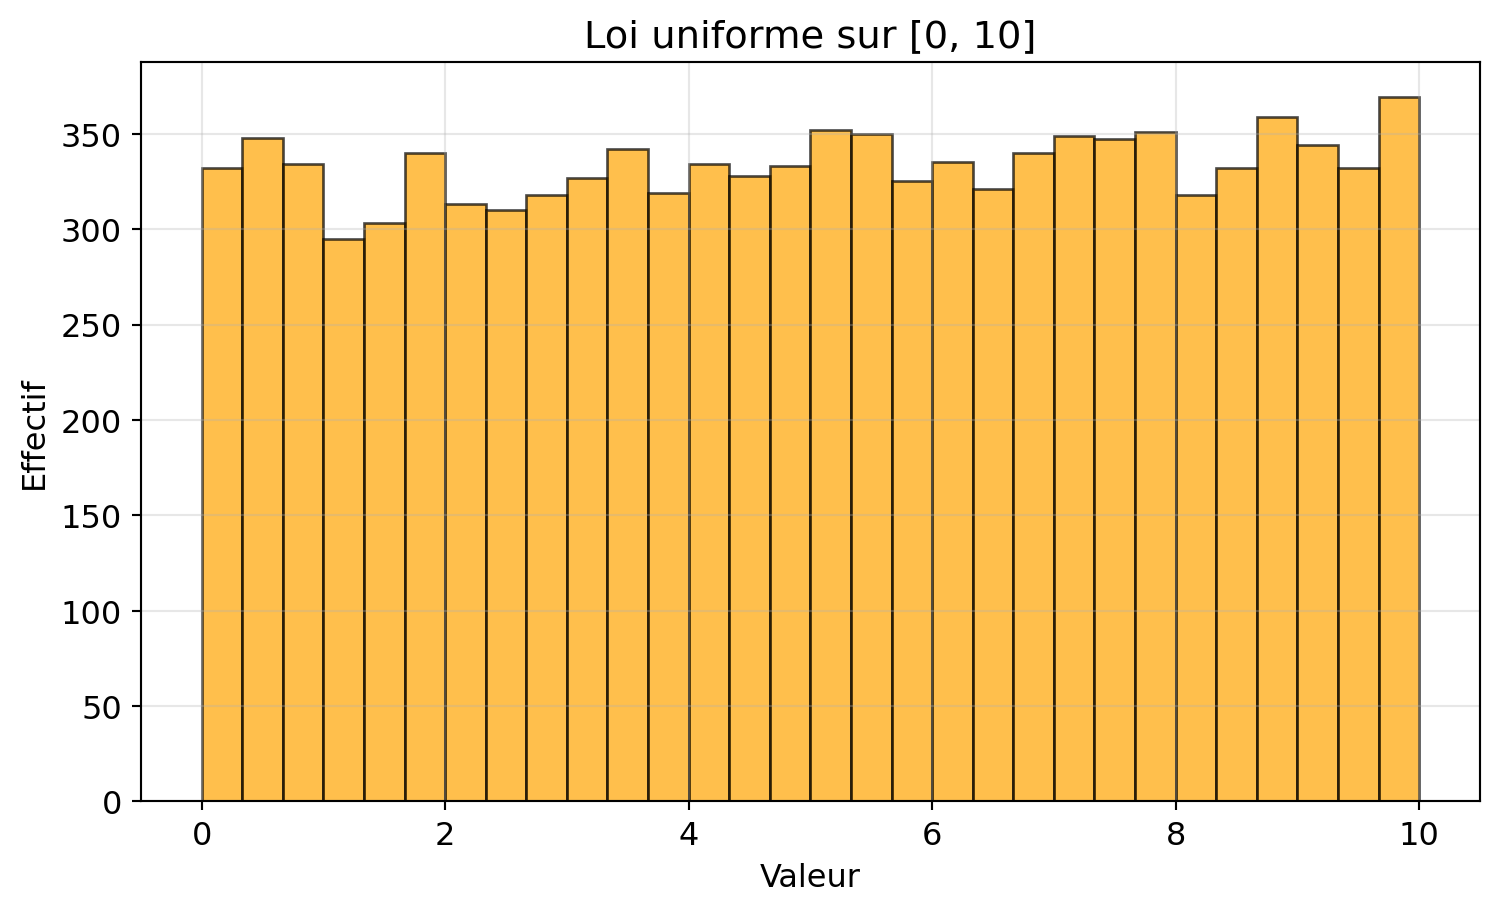

In [18]:
#| label: fig-uniforme
#| fig-cap: 'Loi uniforme : toutes les valeurs sont équiprobables'
tirages_unif = np.random.uniform(0, 10, 10000)

fig, ax = plt.subplots()
ax.hist(tirages_unif, bins=30, edgecolor='black', color='orange', alpha=0.7)
ax.set_title("Loi uniforme sur [0, 10]")
ax.set_xlabel("Valeur")
ax.set_ylabel("Effectif")
ax.grid(True, alpha=0.3)
plt.show()

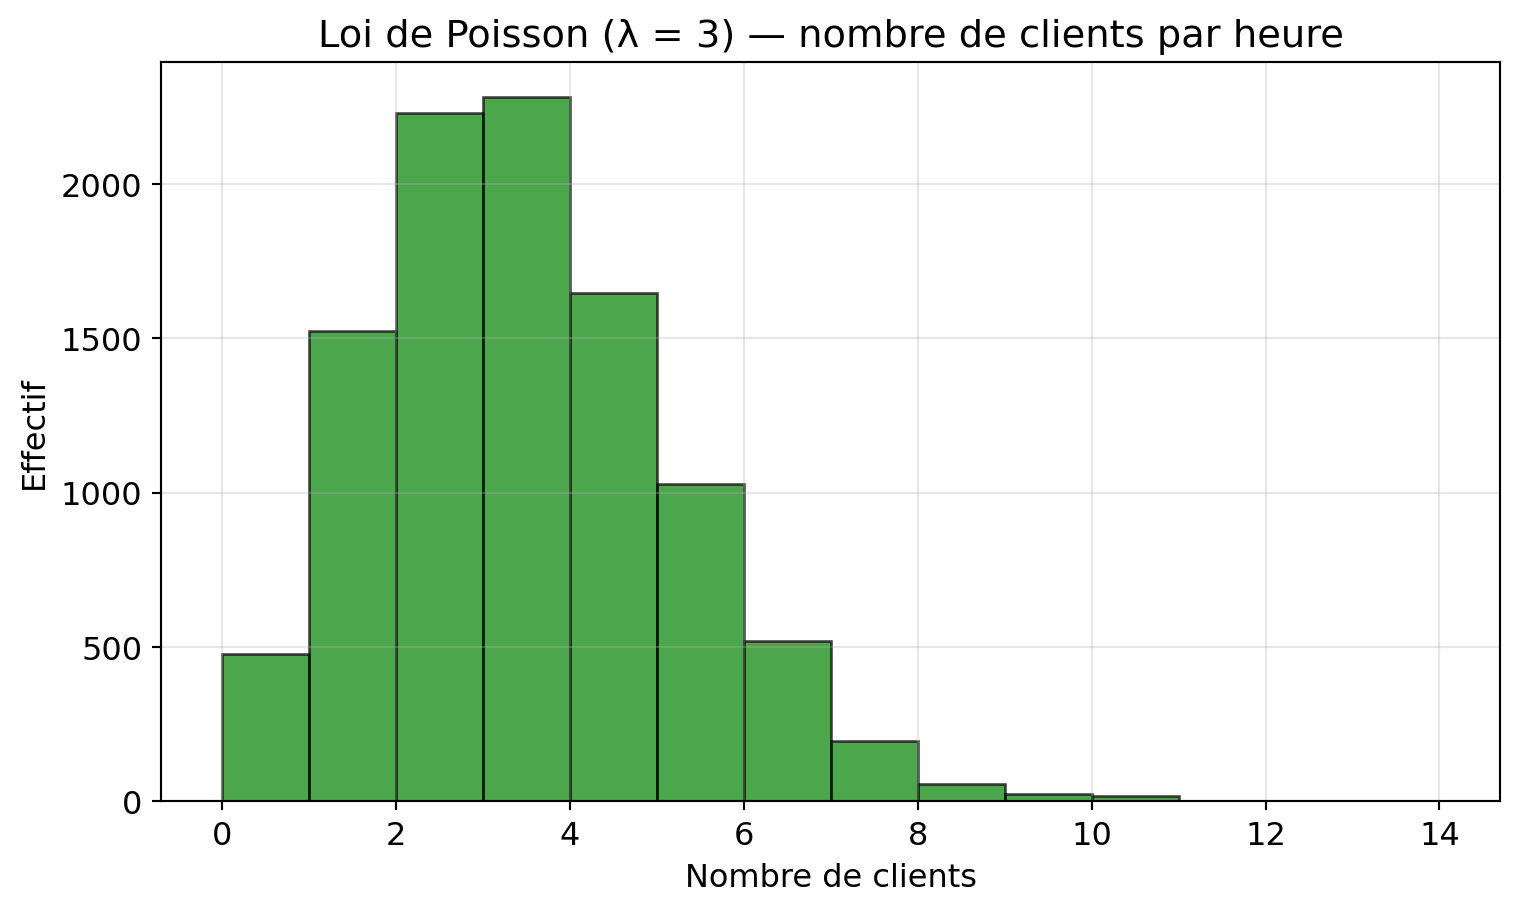

In [19]:
#| label: fig-poisson
#| fig-cap: 'Loi de Poisson : nombre d''événements en un temps fixe'
# En moyenne 3 clients par heure
tirages_poisson = np.random.poisson(lam=3, size=10000)

fig, ax = plt.subplots()
ax.hist(tirages_poisson, bins=range(15), edgecolor='black', color='green', alpha=0.7)
ax.set_title("Loi de Poisson (λ = 3) — nombre de clients par heure")
ax.set_xlabel("Nombre de clients")
ax.set_ylabel("Effectif")
ax.grid(True, alpha=0.3)
plt.show()

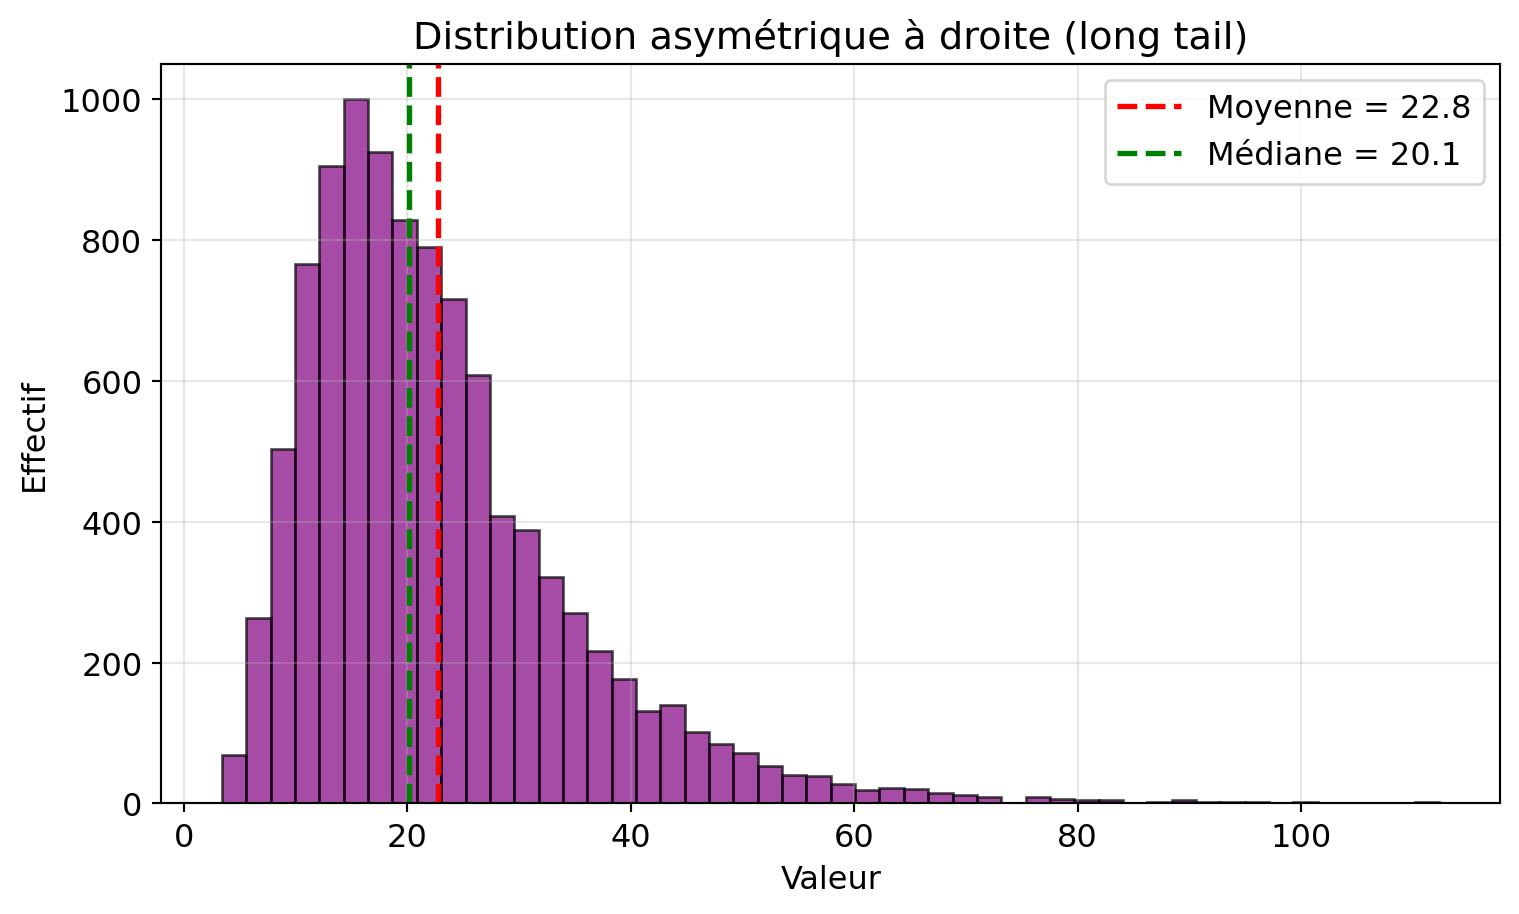

Moyenne (22.8) > Médiane (20.1)
→ C'est la signature d'une distribution asymétrique à droite


In [20]:
#| label: fig-skewed
#| fig-cap: 'Distribution asymétrique : cas typique des salaires ou prix'
# Loi log-normale : souvent utilisée pour modéliser les revenus
revenus_simules = np.random.lognormal(mean=3, sigma=0.5, size=10000)

fig, ax = plt.subplots()
ax.hist(revenus_simules, bins=50, edgecolor='black', color='purple', alpha=0.7)
ax.axvline(np.mean(revenus_simules), color='red', linestyle='--', 
           linewidth=2, label=f'Moyenne = {np.mean(revenus_simules):.1f}')
ax.axvline(np.median(revenus_simules), color='green', linestyle='--', 
           linewidth=2, label=f'Médiane = {np.median(revenus_simules):.1f}')
ax.set_title("Distribution asymétrique à droite (long tail)")
ax.set_xlabel("Valeur")
ax.set_ylabel("Effectif")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Moyenne ({np.mean(revenus_simules):.1f}) > Médiane ({np.median(revenus_simules):.1f})")
print("→ C'est la signature d'une distribution asymétrique à droite")

In [21]:
#| eval: false
# TODO: Exercice 2

# 3 tirages


# 3 histogrammes côte à côte

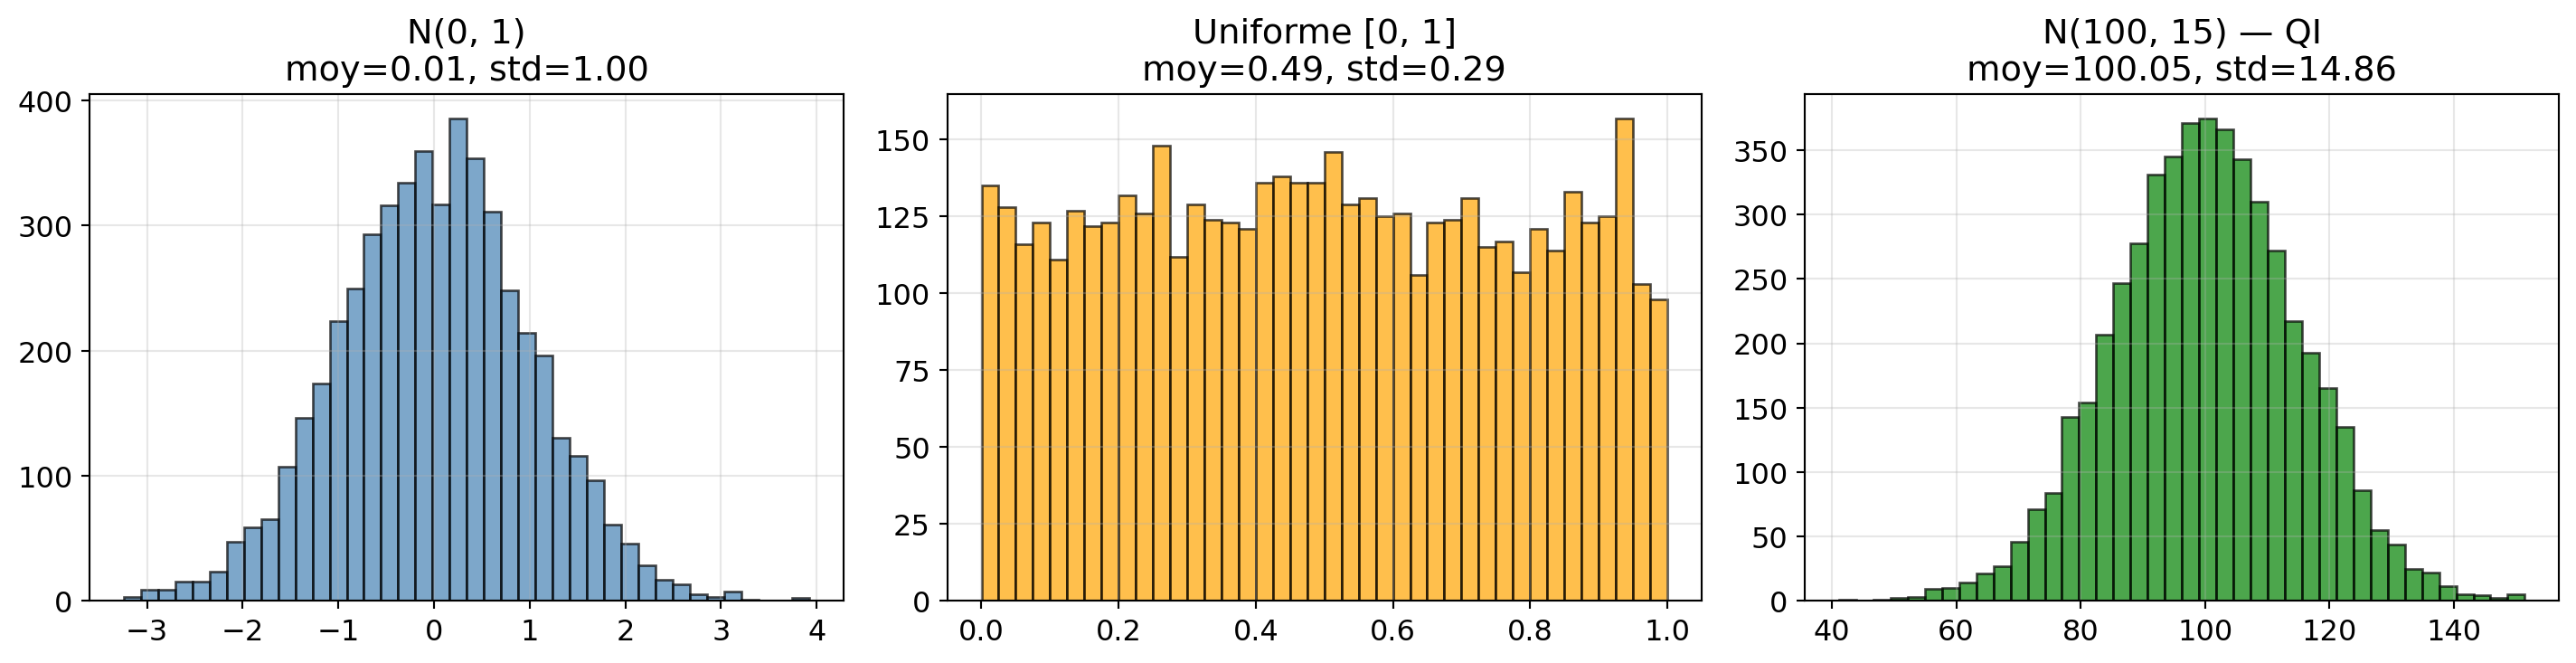

In [22]:
np.random.seed(42)

# 3 tirages
t1 = np.random.normal(0, 1, 5000)
t2 = np.random.uniform(0, 1, 5000)
t3 = np.random.normal(100, 15, 5000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(t1, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f"N(0, 1)\nmoy={t1.mean():.2f}, std={t1.std():.2f}")
axes[0].grid(True, alpha=0.3)

axes[1].hist(t2, bins=40, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title(f"Uniforme [0, 1]\nmoy={t2.mean():.2f}, std={t2.std():.2f}")
axes[1].grid(True, alpha=0.3)

axes[2].hist(t3, bins=40, color='green', edgecolor='black', alpha=0.7)
axes[2].set_title(f"N(100, 15) — QI\nmoy={t3.mean():.2f}, std={t3.std():.2f}")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Simulons 10 000 lancers de pièce
n_lancers = 10000
lancers = np.random.choice(['pile', 'face'], size=n_lancers)

proportion_pile = np.mean(lancers == 'pile')
print(f"Sur {n_lancers} lancers : proportion de 'pile' = {proportion_pile:.4f}")
print(f"Probabilité théorique   : 0.5")

Sur 10000 lancers : proportion de 'pile' = 0.5080
Probabilité théorique   : 0.5


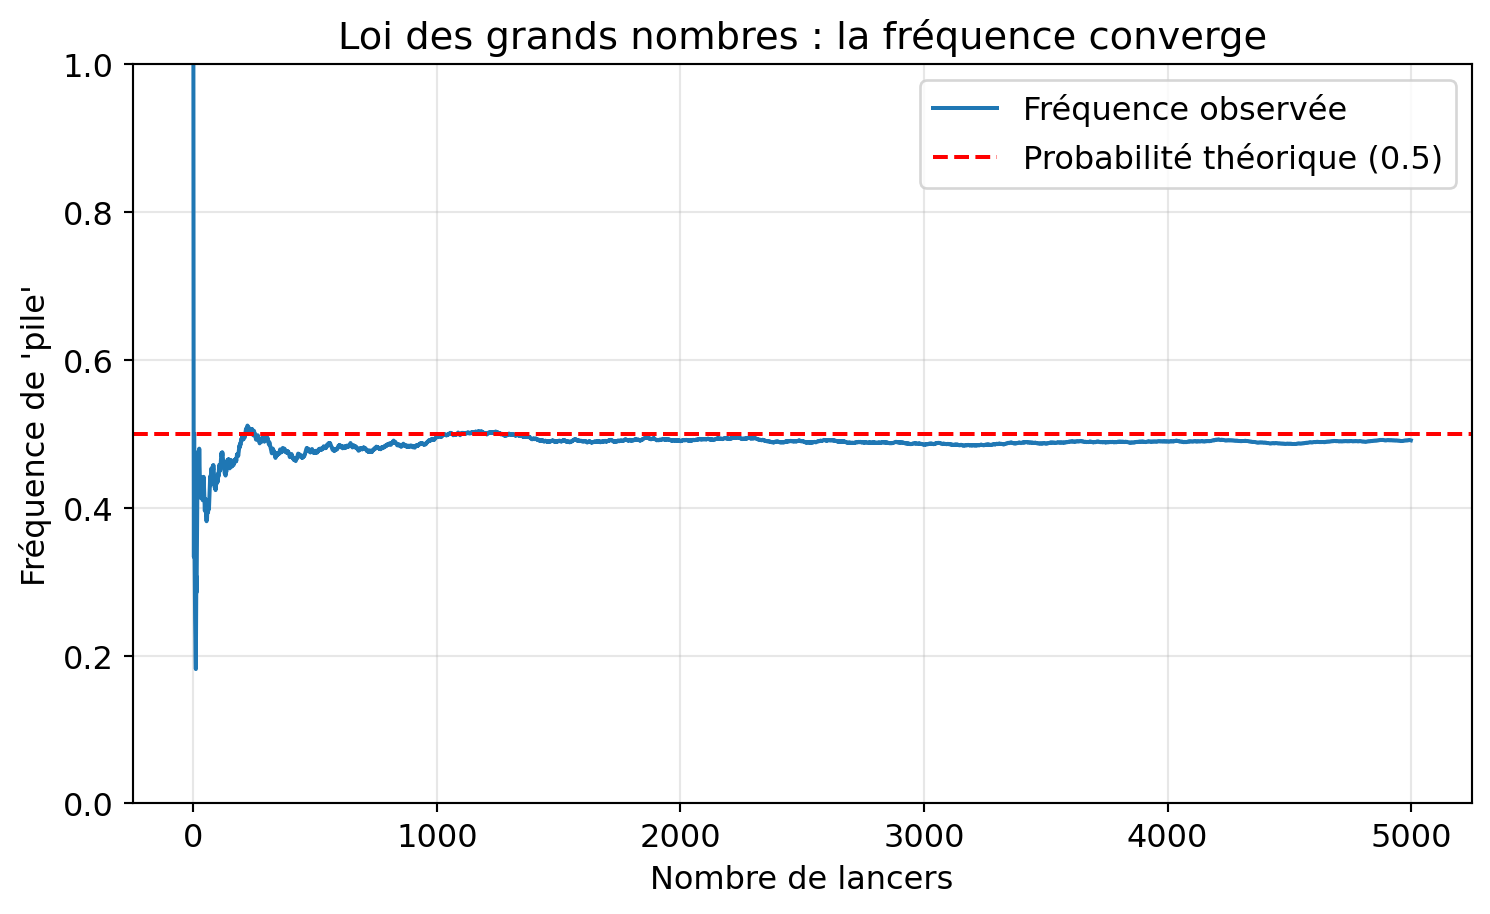

In [24]:
#| label: fig-grands-nombres
#| fig-cap: La fréquence converge vers la probabilité théorique
# Simulons et traçons l'évolution de la fréquence
np.random.seed(0)
lancers = np.random.choice([1, 0], size=5000)  # 1 = pile
frequences = np.cumsum(lancers) / np.arange(1, len(lancers) + 1)

fig, ax = plt.subplots()
ax.plot(frequences, label='Fréquence observée')
ax.axhline(0.5, color='red', linestyle='--', label='Probabilité théorique (0.5)')
ax.set_xlabel("Nombre de lancers")
ax.set_ylabel("Fréquence de 'pile'")
ax.set_title("Loi des grands nombres : la fréquence converge")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [25]:
# Simulation
np.random.seed(42)
n = 100000
lancer_1 = np.random.choice([0, 1], size=n)
lancer_2 = np.random.choice([0, 1], size=n)

p_pile_pile_empirique = np.mean((lancer_1 == 1) & (lancer_2 == 1))
print(f"Empirique    : {p_pile_pile_empirique:.4f}")
print(f"Théorique    : 0.5 × 0.5 = 0.25")

Empirique    : 0.2504
Théorique    : 0.5 × 0.5 = 0.25


In [26]:
# Notations :
# A = "être malade"
# B = "test positif"

P_A = 0.01          # P(malade) = 1%
P_B_sachant_A = 0.95  # P(test+ | malade) = 95%
P_B_sachant_nonA = 0.05  # P(test+ | sain) = 5%

# On a besoin de P(B) = probabilité totale d'être testé positif
# P(B) = P(B|A) × P(A) + P(B|non A) × P(non A)
P_B = P_B_sachant_A * P_A + P_B_sachant_nonA * (1 - P_A)

# Théorème de Bayes
P_A_sachant_B = (P_B_sachant_A * P_A) / P_B

print(f"P(malade | test positif) = {P_A_sachant_B:.1%}")

P(malade | test positif) = 16.1%


In [27]:
# Simulation sur 100 000 personnes
np.random.seed(0)
n_personnes = 100000

# Qui est malade ?
est_malade = np.random.random(n_personnes) < 0.01

# Résultat du test
# Si malade : 95% de chance d'être positif
# Si sain   : 5% de chance d'être positif
test_positif = np.where(
    est_malade,
    np.random.random(n_personnes) < 0.95,
    np.random.random(n_personnes) < 0.05
)

# Parmi les testés positifs, combien sont vraiment malades ?
malades_parmi_positifs = np.sum(est_malade & test_positif)
total_positifs = np.sum(test_positif)

print(f"Malades réels           : {est_malade.sum()}")
print(f"Testés positifs         : {total_positifs}")
print(f"Vraiment malades parmi positifs : {malades_parmi_positifs}")
print(f"Proportion : {malades_parmi_positifs / total_positifs:.1%}")
print(f"→ Cohérent avec notre calcul de Bayes (~16%) !")

Malades réels           : 1007
Testés positifs         : 5941
Vraiment malades parmi positifs : 958
Proportion : 16.1%
→ Cohérent avec notre calcul de Bayes (~16%) !


In [28]:
#| eval: false
# TODO: Exercice 3

# 1-3. Trois séries


# 4. Bonus : évolution

n =    100 : proportion de 6 = 0.1400  (écart à 1/6 : 0.0267)
n =   1000 : proportion de 6 = 0.1750  (écart à 1/6 : 0.0083)
n = 100000 : proportion de 6 = 0.1662  (écart à 1/6 : 0.0005)


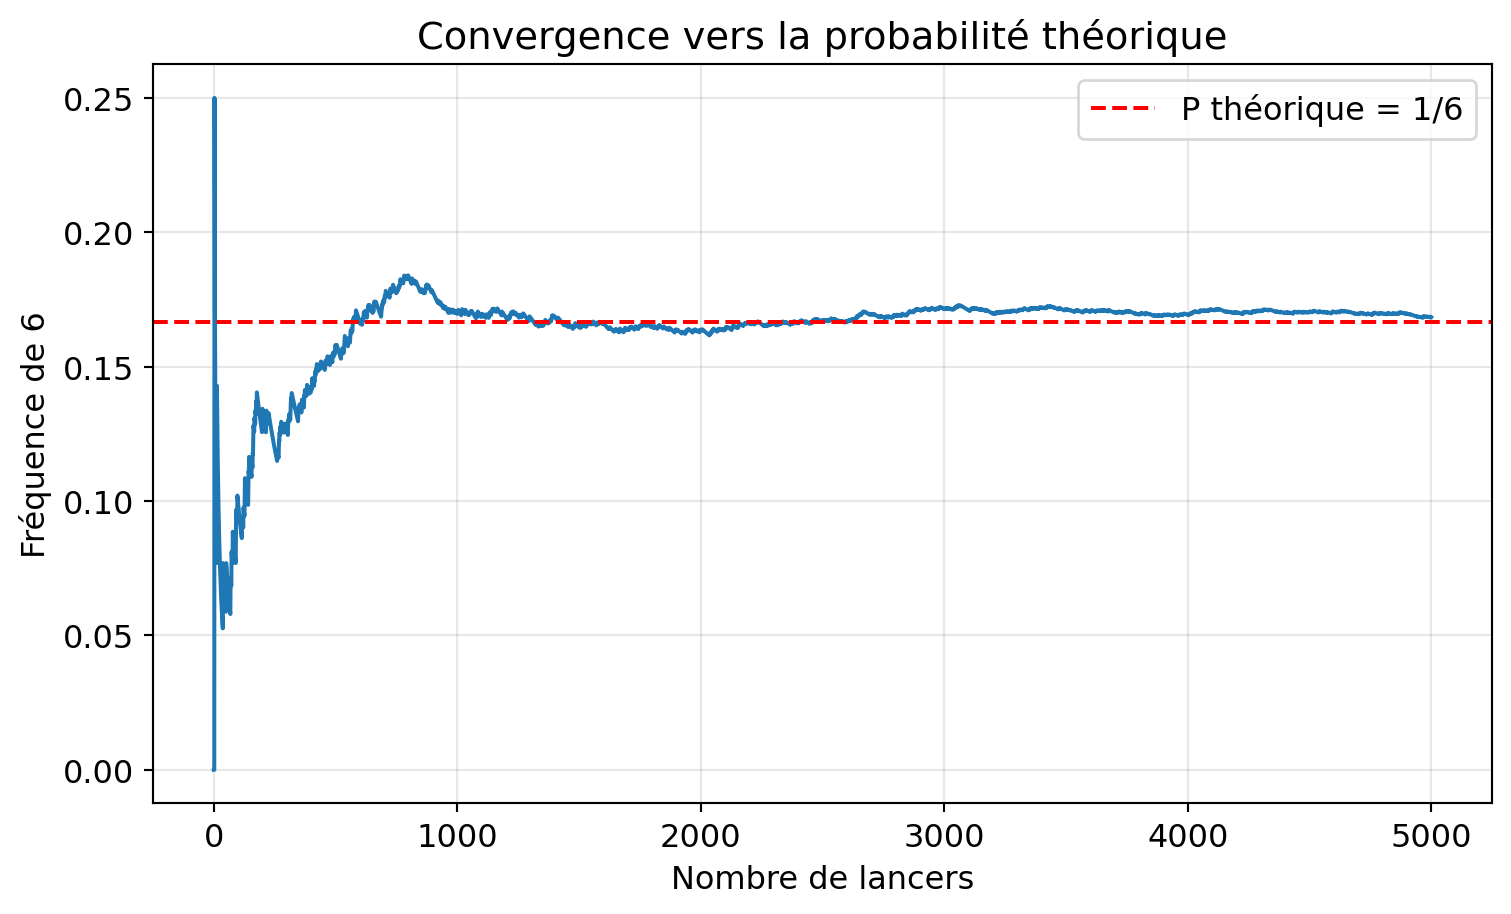

In [29]:
np.random.seed(0)

# 1-3. Trois séries
for n in [100, 1000, 100000]:
    lancers = np.random.randint(1, 7, size=n)
    proportion_6 = np.mean(lancers == 6)
    ecart = abs(proportion_6 - 1/6)
    print(f"n = {n:6d} : proportion de 6 = {proportion_6:.4f}  "
          f"(écart à 1/6 : {ecart:.4f})")

# 4. Évolution
n_lancers = 5000
lancers = np.random.randint(1, 7, size=n_lancers)
est_6 = (lancers == 6).astype(int)
frequences = np.cumsum(est_6) / np.arange(1, n_lancers + 1)

fig, ax = plt.subplots()
ax.plot(frequences)
ax.axhline(1/6, color='red', linestyle='--', label='P théorique = 1/6')
ax.set_xlabel("Nombre de lancers")
ax.set_ylabel("Fréquence de 6")
ax.set_title("Convergence vers la probabilité théorique")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [30]:
#| eval: false
# TODO: Exercice 4

# 1-3. Calcul analytique


# 4. Simulation

In [31]:
# 1. Probabilités
P_A = 0.80
P_B = 0.20
P_def_sachant_A = 0.02
P_def_sachant_B = 0.10

# 2. Probabilité totale de défaut
P_def = P_def_sachant_A * P_A + P_def_sachant_B * P_B
print(f"P(défaut) = {P_def:.4f}")

# 3. Bayes
P_B_sachant_def = (P_def_sachant_B * P_B) / P_def
print(f"P(usine B | défaut) = {P_B_sachant_def:.4f} ({P_B_sachant_def:.1%})")

# 4. Simulation
np.random.seed(0)
n = 1000000
# Chaque lampe : de quelle usine ?
usine = np.where(np.random.random(n) < 0.80, 'A', 'B')
# Chaque lampe : défectueuse ?
defect = np.where(
    usine == 'A',
    np.random.random(n) < 0.02,
    np.random.random(n) < 0.10
)
# Parmi les défectueuses, quelle proportion vient de B ?
b_parmi_def = np.sum((usine == 'B') & defect) / np.sum(defect)
print(f"\nSimulation : P(B | défaut) ≈ {b_parmi_def:.4f}")

P(défaut) = 0.0360
P(usine B | défaut) = 0.5556 (55.6%)

Simulation : P(B | défaut) ≈ 0.5586


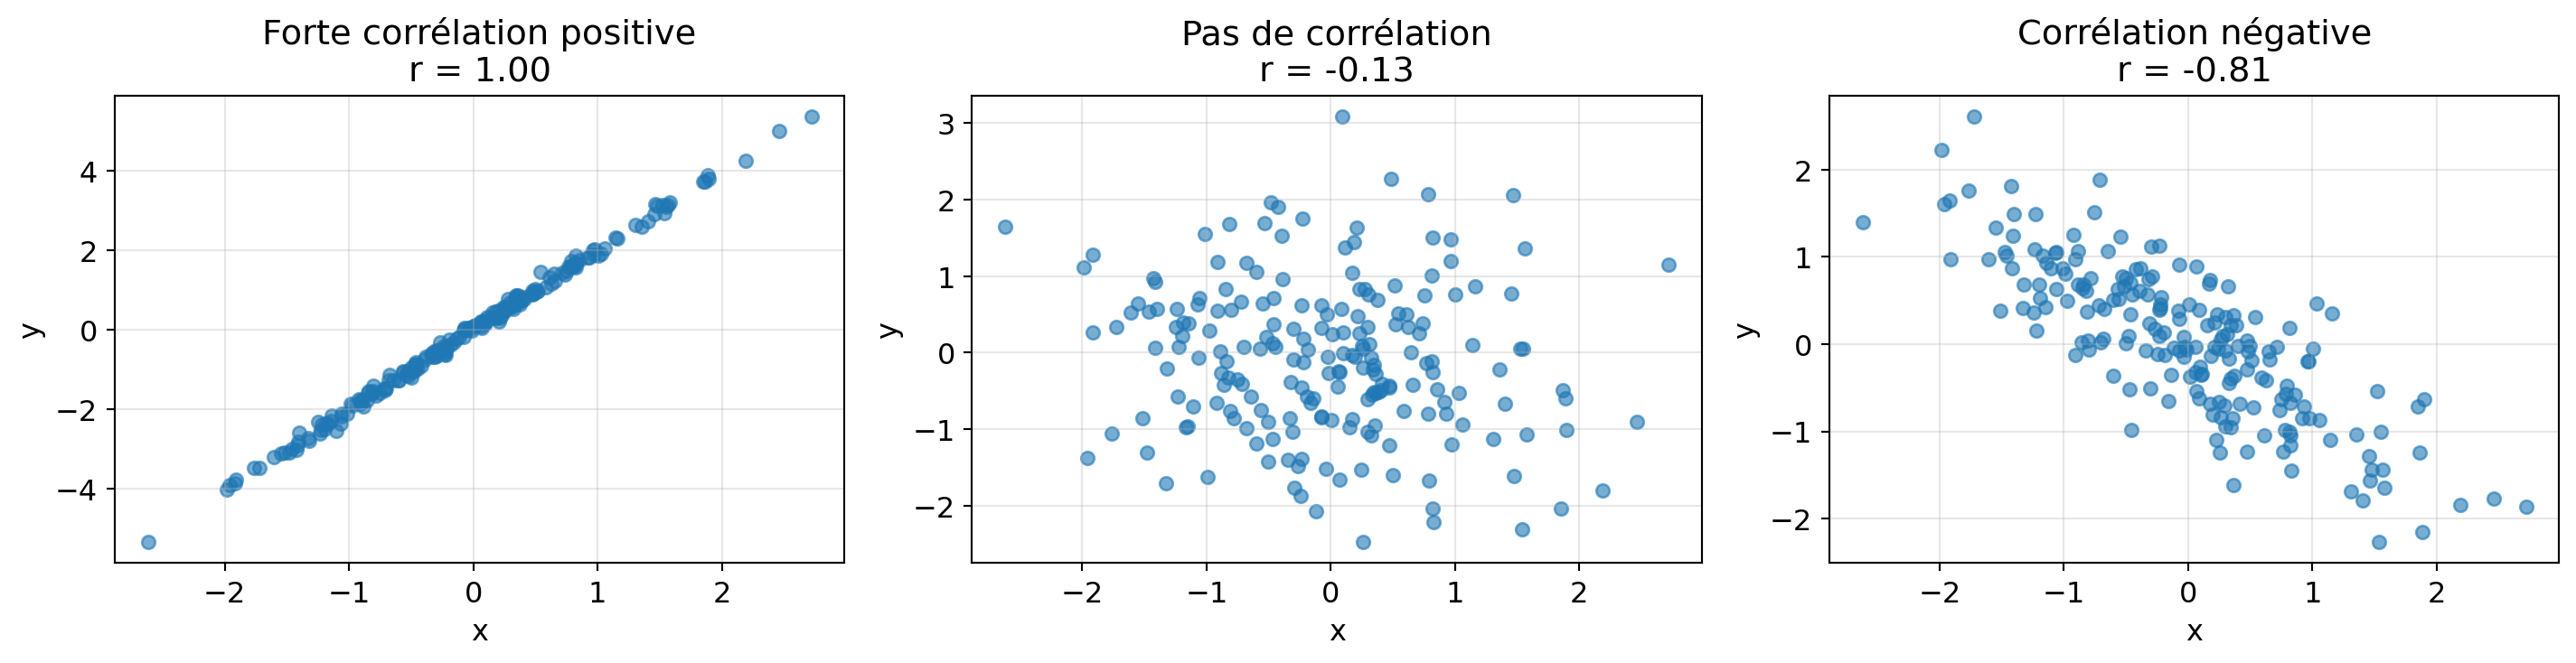

In [32]:
#| label: fig-correlations
#| fig-cap: Différents niveaux de corrélation
np.random.seed(42)
n = 200

# Trois cas
x_all = np.random.randn(n)

# r ≈ 1
y1 = 2 * x_all + np.random.randn(n) * 0.1

# r ≈ 0
y2 = np.random.randn(n)

# r ≈ -0.8
y3 = -0.8 * x_all + np.random.randn(n) * 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y, titre in zip(axes, [y1, y2, y3], 
                        ['Forte corrélation positive', 'Pas de corrélation', 'Corrélation négative']):
    r = np.corrcoef(x_all, y)[0, 1]
    ax.scatter(x_all, y, alpha=0.6, s=30)
    ax.set_title(f"{titre}\nr = {r:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Exemple concret : taille et poids
np.random.seed(1)
tailles = np.random.normal(170, 10, 50)
poids = 0.85 * tailles - 70 + np.random.normal(0, 5, 50)

# Méthode 1 : np.corrcoef
matrice_corr = np.corrcoef(tailles, poids)
print(f"Coefficient de corrélation : {matrice_corr[0, 1]:.3f}")

# Méthode 2 : scipy (donne aussi la p-value)
from scipy.stats import pearsonr
r, p_value = pearsonr(tailles, poids)
print(f"r = {r:.3f}, p-value = {p_value:.2e}")

Coefficient de corrélation : 0.902


r = 0.902, p-value = 4.25e-19


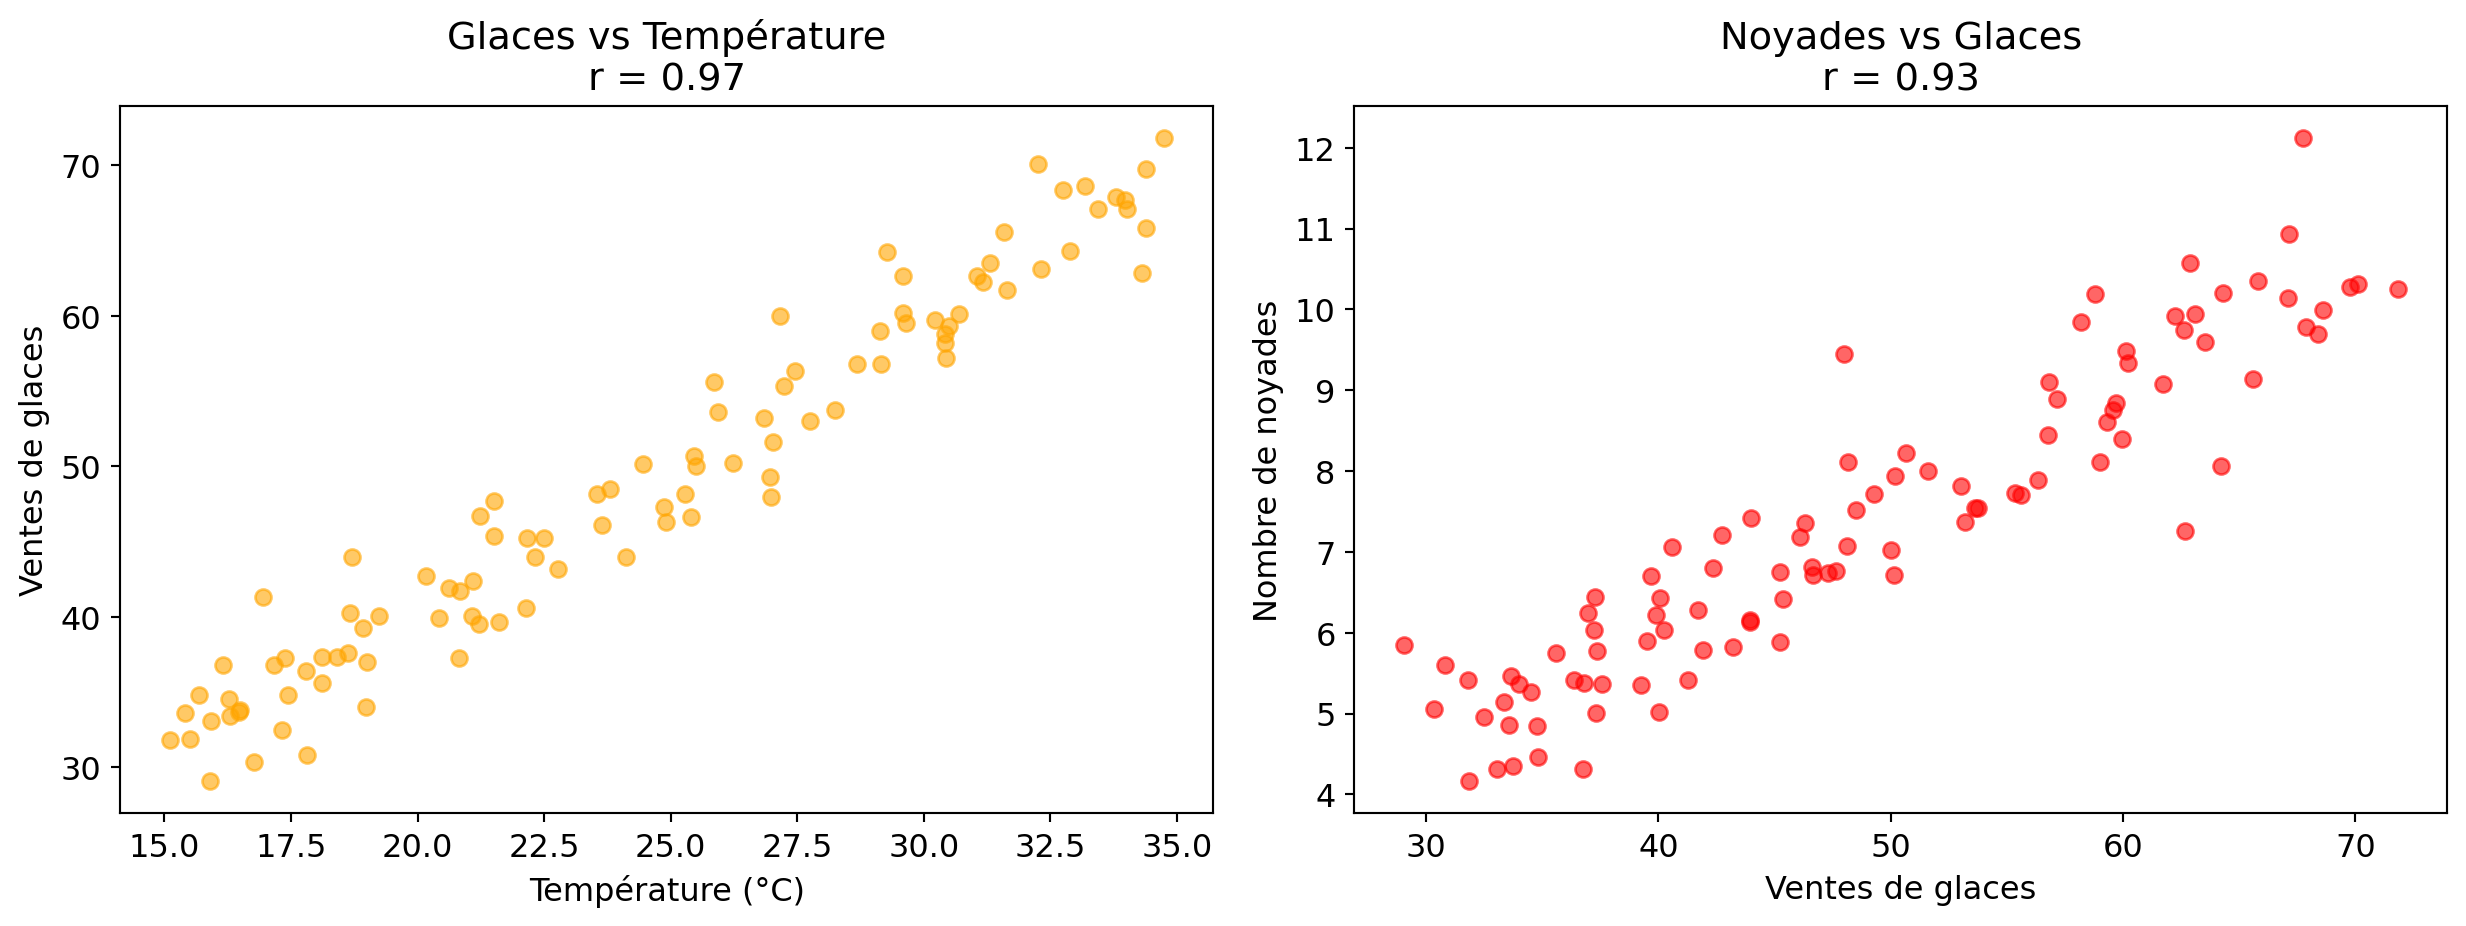

In [34]:
#| label: fig-correlation-spurieuse
#| fig-cap: Deux variables corrélées... mais sans lien de cause à effet
np.random.seed(42)
# Simulons 100 jours d'été
temperature = np.random.uniform(15, 35, 100)  # °C
ventes_glaces = 2 * temperature + np.random.normal(0, 3, 100)
noyades = 0.3 * temperature + np.random.normal(0, 0.5, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(temperature, ventes_glaces, alpha=0.6, color='orange')
axes[0].set_xlabel("Température (°C)")
axes[0].set_ylabel("Ventes de glaces")
axes[0].set_title(f"Glaces vs Température\nr = {np.corrcoef(temperature, ventes_glaces)[0, 1]:.2f}")

axes[1].scatter(ventes_glaces, noyades, alpha=0.6, color='red')
axes[1].set_xlabel("Ventes de glaces")
axes[1].set_ylabel("Nombre de noyades")
axes[1].set_title(f"Noyades vs Glaces\nr = {np.corrcoef(ventes_glaces, noyades)[0, 1]:.2f}")

plt.tight_layout()
plt.show()

In [35]:
#| eval: false
# TODO: Exercice 5

# 1. Données et corrélation


# 2. Scatter plot


# 3-4. Réflexion (cellule markdown)

Corrélation entre TP et DS : r = 0.788


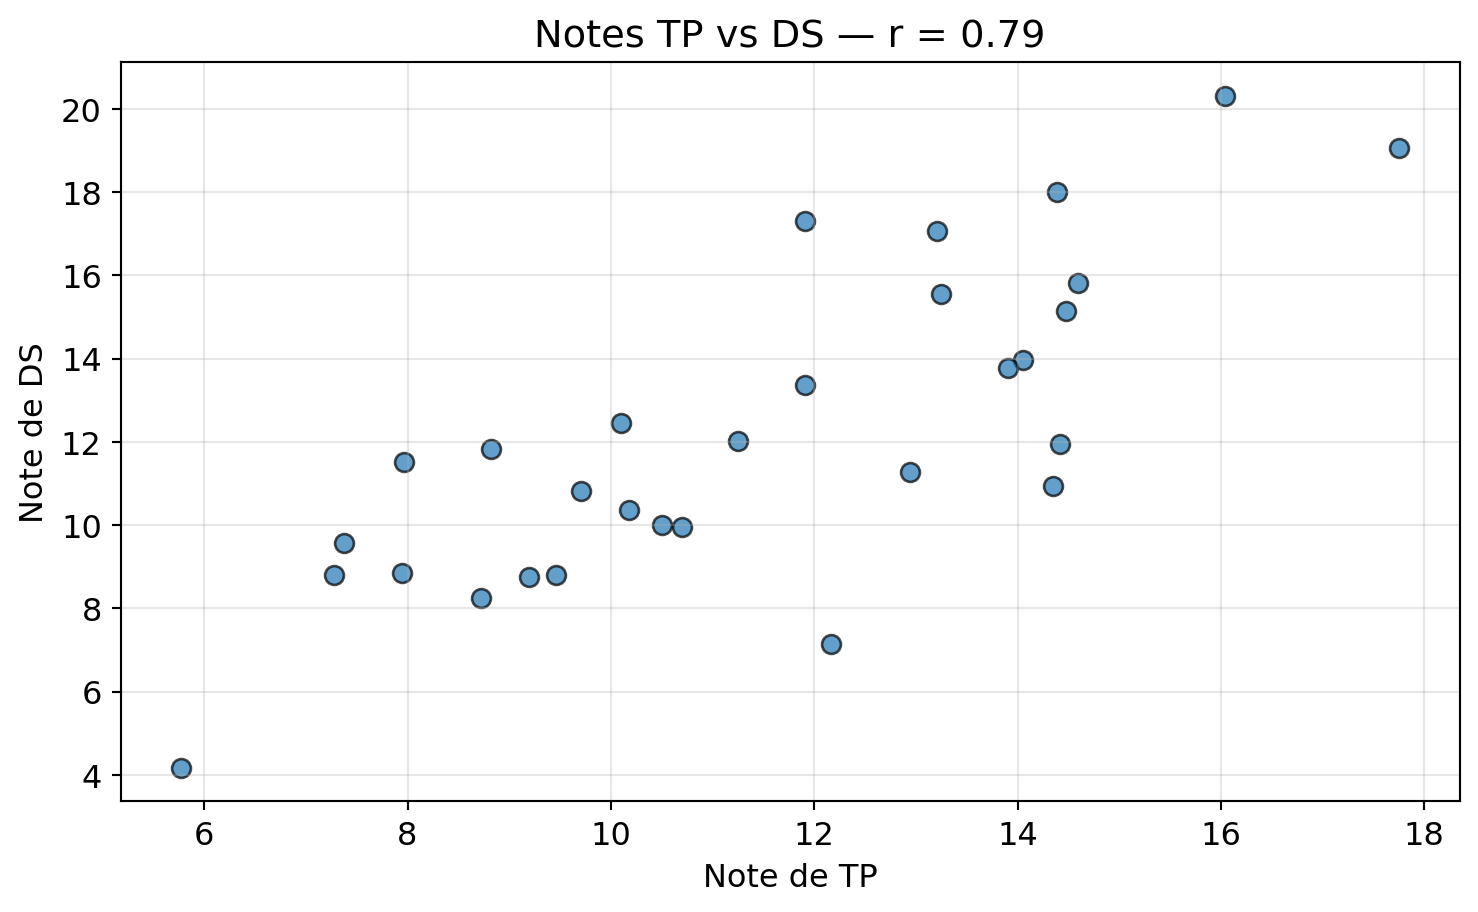

In [36]:
np.random.seed(123)
tp = np.random.uniform(5, 18, 30)
ds = 0.8 * tp + 3 + np.random.normal(0, 2, 30)

r = np.corrcoef(tp, ds)[0, 1]
print(f"Corrélation entre TP et DS : r = {r:.3f}")

fig, ax = plt.subplots()
ax.scatter(tp, ds, alpha=0.7, s=50, edgecolor='k')
ax.set_xlabel("Note de TP")
ax.set_ylabel("Note de DS")
ax.set_title(f"Notes TP vs DS — r = {r:.2f}")
ax.grid(True, alpha=0.3)
plt.show()

In [37]:
#| eval: false
# TODO: Exercice 6

temperatures = np.array([
    21.5, 22.1, 21.8, 22.4, 21.9, 22.2, 21.7, 22.0, 21.6, 22.3,
    21.8, 22.1, 21.9, 22.0, 95.5, 22.2, 21.7, 22.4, 21.6, 22.0,
    21.9, 22.1, -15.2, 22.3, 21.8, 22.0, 21.7, 22.2, 21.9, 22.1
])

# 1. Stats initiales


# 2. Détection outliers


# 3. Nettoyage et nouvelles stats


# 4. Comparaison

In [38]:
temperatures = np.array([
    21.5, 22.1, 21.8, 22.4, 21.9, 22.2, 21.7, 22.0, 21.6, 22.3,
    21.8, 22.1, 21.9, 22.0, 95.5, 22.2, 21.7, 22.4, 21.6, 22.0,
    21.9, 22.1, -15.2, 22.3, 21.8, 22.0, 21.7, 22.2, 21.9, 22.1
])

# 1. Stats initiales
mu = temperatures.mean()
sigma = temperatures.std()
print(f"Avec outliers : μ = {mu:.2f}, σ = {sigma:.2f}")

# 2. Détection (méthode 3-sigma)
seuil_bas = mu - 3 * sigma
seuil_haut = mu + 3 * sigma
outliers = temperatures[(temperatures < seuil_bas) | (temperatures > seuil_haut)]
print(f"Bornes : [{seuil_bas:.2f}, {seuil_haut:.2f}]")
print(f"Outliers détectés : {outliers}")

# 3. Nettoyage
temps_clean = temperatures[(temperatures >= seuil_bas) & (temperatures <= seuil_haut)]
mu_clean = temps_clean.mean()
sigma_clean = temps_clean.std()
print(f"\nSans outliers : μ = {mu_clean:.2f}, σ = {sigma_clean:.2f}")

# 4. Impact
print(f"\nDifférence de moyenne : {abs(mu - mu_clean):.2f}°C")
print(f"Division de l'écart-type : {sigma / sigma_clean:.1f}x")

Avec outliers : μ = 23.18, σ = 15.00
Bornes : [-21.80, 68.17]
Outliers détectés : [95.5]

Sans outliers : μ = 20.69, σ = 6.79

Différence de moyenne : 2.49°C
Division de l'écart-type : 2.2x


In [39]:
#| eval: false
# TODO: Exercice bilan

np.random.seed(42)
jours = np.arange(365)
saisonnalite = 100 * np.sin(2 * np.pi * jours / 365)
tendance = 0.5 * jours
bruit = np.random.normal(0, 50, 365)
ventes = 500 + saisonnalite + tendance + bruit

# 1. Résumé statistique


# 2. Visualisations


# 3. Outliers


# 4. Moyenne par jour de la semaine


# 5. Corrélation temps-ventes


# Conclusion dans une cellule markdown

=== Résumé statistique ===
Moyenne    : 591.5
Médiane    : 592.3
Min / Max  : 371.0 / 772.7
Écart-type : 65.1
Q1 / Q3    : 547.2 / 640.6


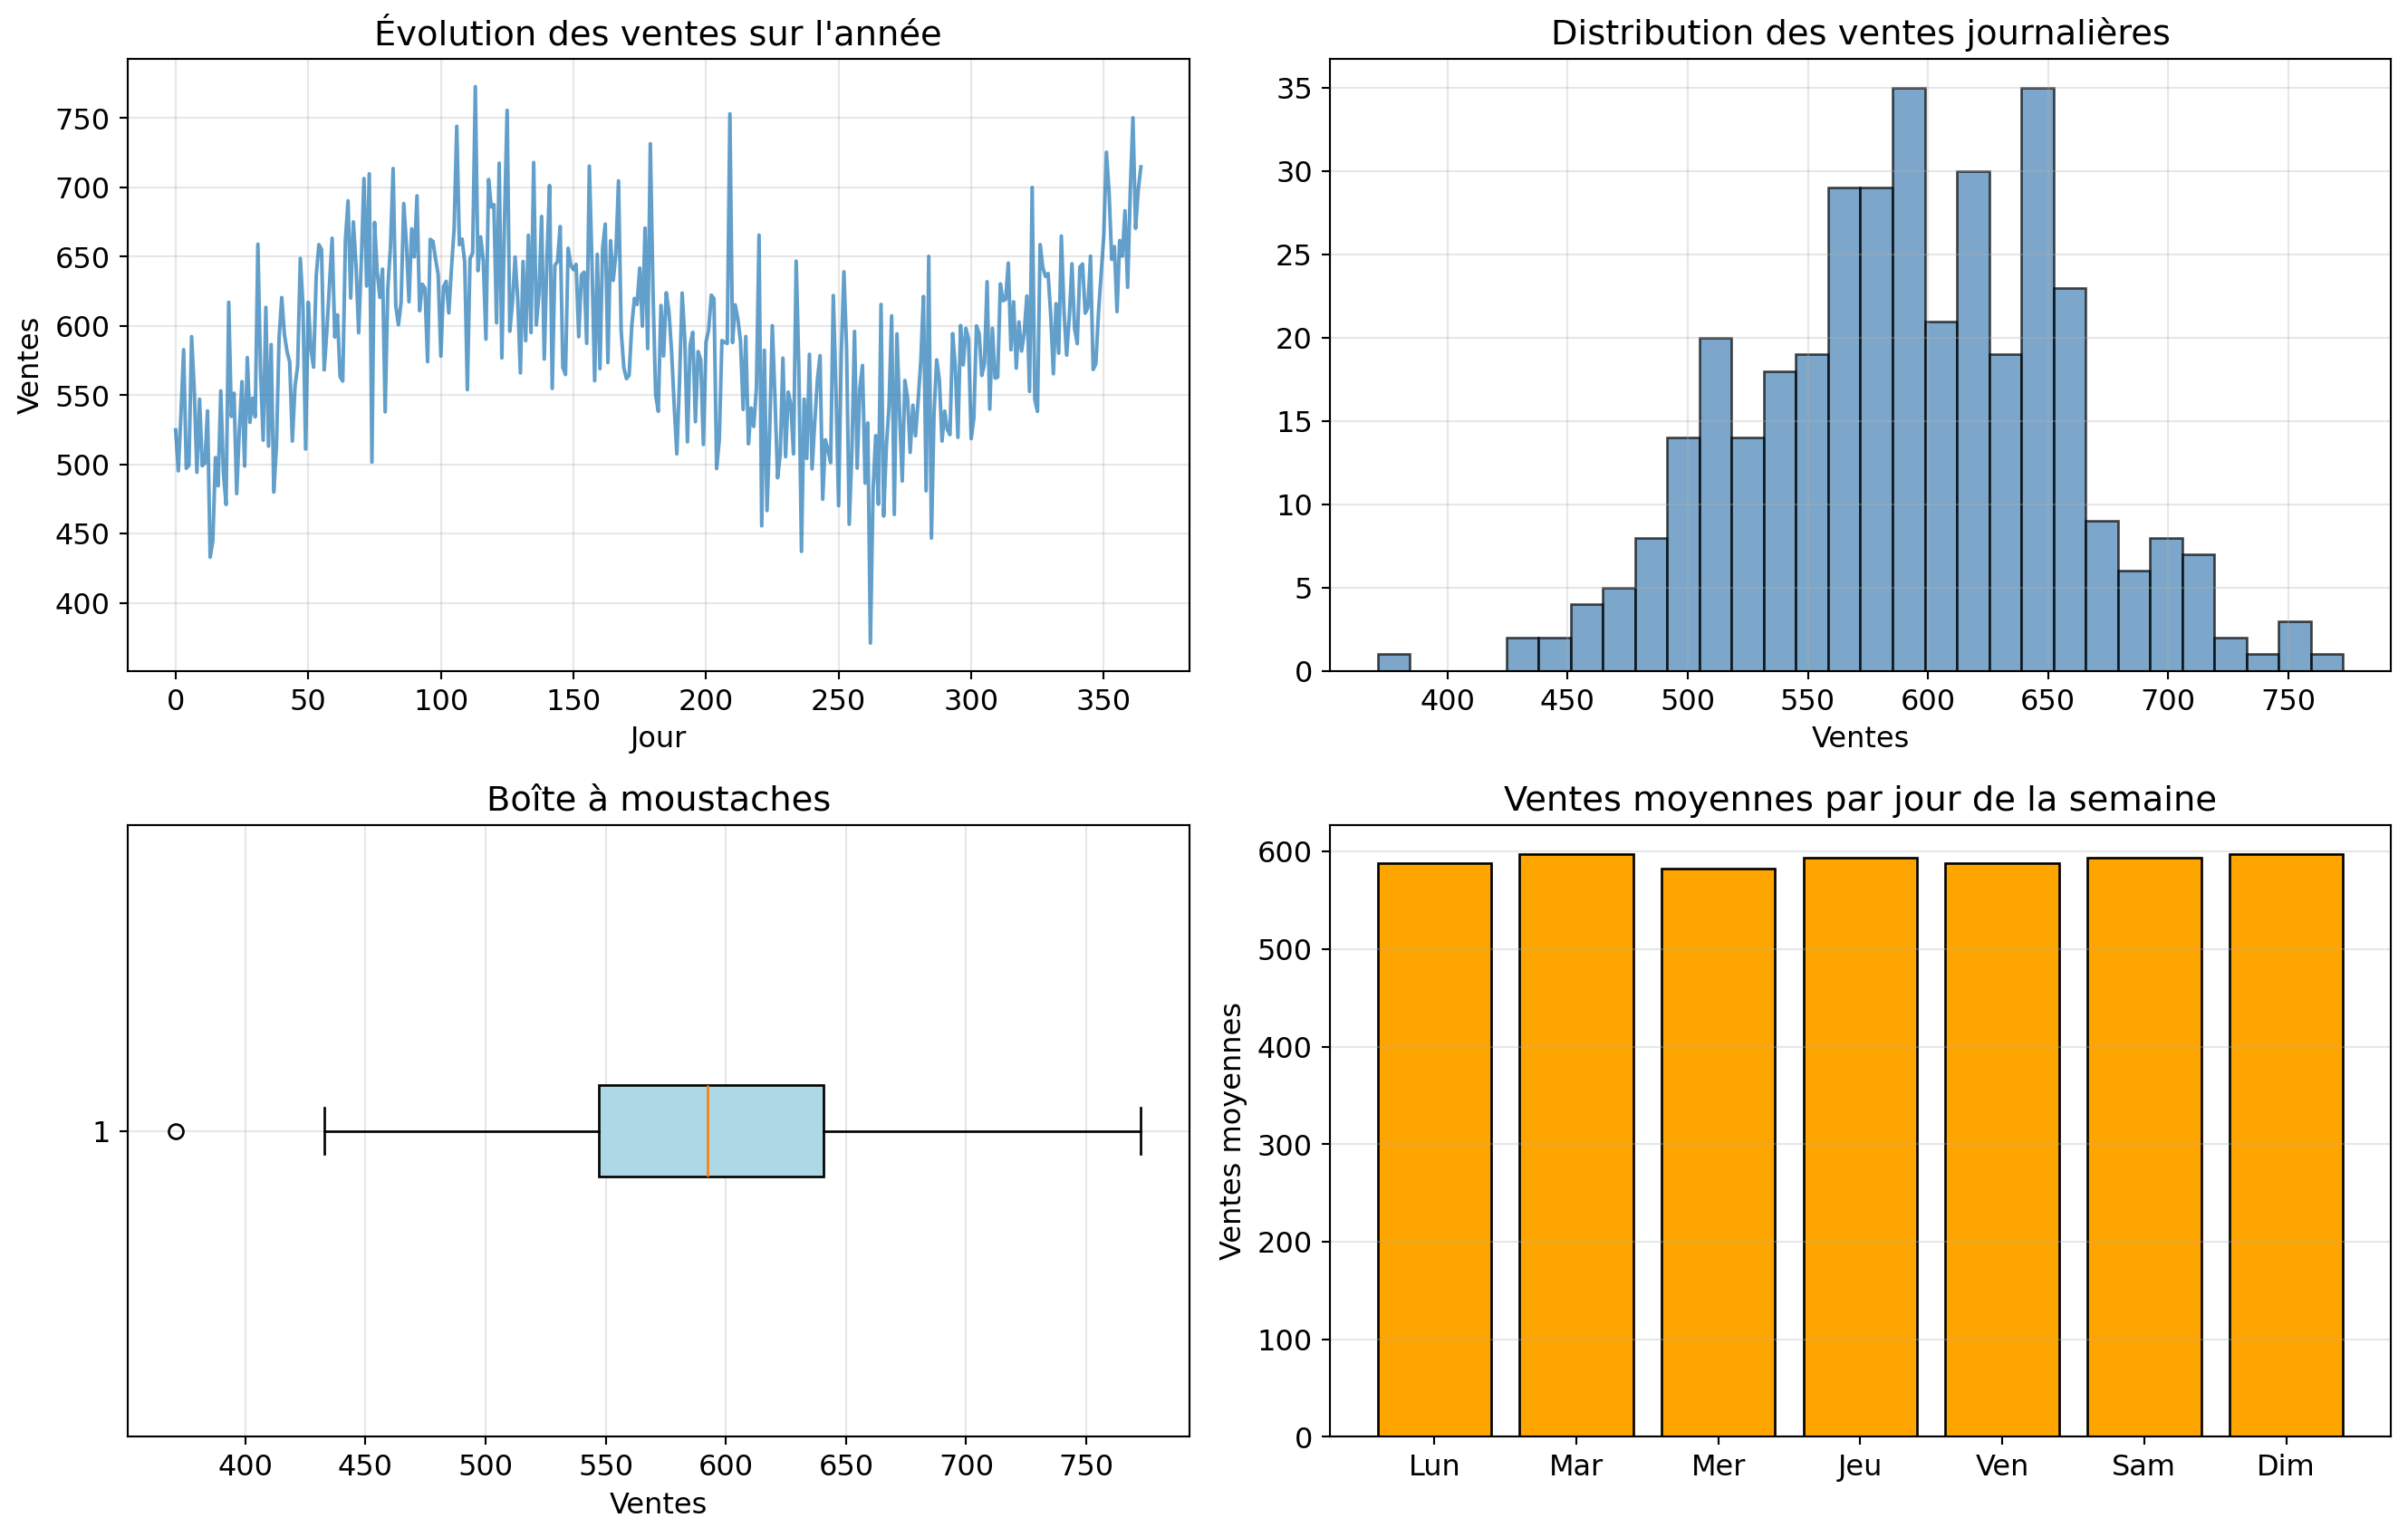


=== Outliers (règle 3σ) ===
Nombre d'outliers : 1
Valeurs : [370.97526383]

=== Ventes moyennes par jour ===
  Lun : 587.7
  Mar : 597.4
  Mer : 582.7
  Jeu : 593.9
  Ven : 588.1
  Sam : 593.3
  Dim : 597.5

Corrélation jour-ventes : r = 0.008


In [40]:
np.random.seed(42)
jours = np.arange(365)
saisonnalite = 100 * np.sin(2 * np.pi * jours / 365)
tendance = 0.5 * jours
bruit = np.random.normal(0, 50, 365)
ventes = 500 + saisonnalite + tendance + bruit

# 1. Résumé
print("=== Résumé statistique ===")
print(f"Moyenne    : {ventes.mean():.1f}")
print(f"Médiane    : {np.median(ventes):.1f}")
print(f"Min / Max  : {ventes.min():.1f} / {ventes.max():.1f}")
print(f"Écart-type : {ventes.std():.1f}")
print(f"Q1 / Q3    : {np.percentile(ventes, 25):.1f} / {np.percentile(ventes, 75):.1f}")

# 2. Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Évolution temporelle
axes[0, 0].plot(jours, ventes, alpha=0.7)
axes[0, 0].set_title("Évolution des ventes sur l'année")
axes[0, 0].set_xlabel("Jour")
axes[0, 0].set_ylabel("Ventes")
axes[0, 0].grid(True, alpha=0.3)

# Histogramme
axes[0, 1].hist(ventes, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 1].set_title("Distribution des ventes journalières")
axes[0, 1].set_xlabel("Ventes")
axes[0, 1].grid(True, alpha=0.3)

# Boxplot
axes[1, 0].boxplot(ventes, vert=False, patch_artist=True, 
                   boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_title("Boîte à moustaches")
axes[1, 0].set_xlabel("Ventes")
axes[1, 0].grid(True, alpha=0.3)

# Moyenne par jour de la semaine
jour_semaine = jours % 7
moy_par_jour = [ventes[jour_semaine == j].mean() for j in range(7)]
noms_jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
axes[1, 1].bar(noms_jours, moy_par_jour, color='orange', edgecolor='black')
axes[1, 1].set_title("Ventes moyennes par jour de la semaine")
axes[1, 1].set_ylabel("Ventes moyennes")
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 3. Outliers
mu = ventes.mean()
sigma = ventes.std()
outliers = ventes[(ventes < mu - 3*sigma) | (ventes > mu + 3*sigma)]
print(f"\n=== Outliers (règle 3σ) ===")
print(f"Nombre d'outliers : {len(outliers)}")
if len(outliers) > 0:
    print(f"Valeurs : {outliers}")

# 4. Analyse jour de la semaine
print("\n=== Ventes moyennes par jour ===")
for nom, moy in zip(noms_jours, moy_par_jour):
    print(f"  {nom} : {moy:.1f}")

# 5. Corrélation temps-ventes
r = np.corrcoef(jours, ventes)[0, 1]
print(f"\nCorrélation jour-ventes : r = {r:.3f}")